# Fraud Detection Using Machine Learning

**Name:** Aparaajetha Suvarnam

**Internship:** Oasis Infobyte (OIBSIP)

**Track:** Data Analytics

**Level:** 2

**Task:** 3 – Fraud Detection

---

## Objective

The objective of this project is to build a machine learning pipeline that detects fraudulent credit card transactions from a highly imbalanced dataset.

Two classification models are developed and compared:

- Logistic Regression
- Random Forest Classifier

The models are evaluated using Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix to determine the most suitable model for fraud detection.

## Import Libraries

The project uses Python libraries for data analysis, visualization, preprocessing, and machine learning.

**Libraries Used**

- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical computations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization
- **Scikit-learn** – Machine learning models and evaluation
- **Imbalanced-learn (SMOTE)** – Handling class imbalance in fraud detection

These libraries provide the complete workflow required for building an end-to-end fraud detection pipeline.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

plt.style.use("ggplot")
%matplotlib inline

## Load Dataset

The **Credit Card Fraud Detection** dataset contains anonymized credit card transactions made by European cardholders.

**Target Variable**

- **Class = 0** → Genuine transaction
- **Class = 1** → Fraudulent transaction

The dataset includes transaction time, transaction amount, and 28 anonymized numerical features (`V1`–`V28`) that preserve customer privacy while retaining useful predictive information.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
df = pd.read_csv("creditcard.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Initial Data Inspection

Before building any machine learning model, it is important to understand the dataset structure.

The inspection includes:

- Dataset shape
- Column names
- Data types
- Missing value check
- Duplicate record check
- Statistical summary of numerical features

This step helps verify that the dataset is suitable for preprocessing and model development.

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
df.describe()

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11     

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Data Cleaning

Data cleaning ensures that the machine learning models learn from reliable and consistent data.

**Cleaning Steps Performed**

- Removed duplicate transactions
- Verified that no missing values exist
- Confirmed data consistency before preprocessing

A clean dataset improves model reliability and prevents repeated records from biasing the training process.

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

print("\nRemaining duplicates:", df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

Shape after removing duplicates: (283726, 31)

Remaining duplicates: 0

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## Class Imbalance Analysis

Fraud detection datasets are highly imbalanced because fraudulent transactions are extremely rare compared to genuine transactions.

This section calculates the percentage of fraudulent and non-fraudulent transactions and visualizes their distribution.

Understanding this imbalance is essential before training machine learning models.

In [ ]:
# Count genuine and fraudulent transactions

class_counts = df["Class"].value_counts()

fraud_percentage = (class_counts[1] / len(df)) * 100
genuine_percentage = (class_counts[0] / len(df)) * 100

print("Genuine Transactions :", class_counts[0])
print("Fraud Transactions   :", class_counts[1])

print(f"\nGenuine Percentage : {genuine_percentage:.4f}%")
print(f"Fraud Percentage    : {fraud_percentage:.4f}%")

Genuine Transactions : 283253
Fraud Transactions   : 473

Genuine Percentage : 99.8333%
Fraud Percentage    : 0.1667%


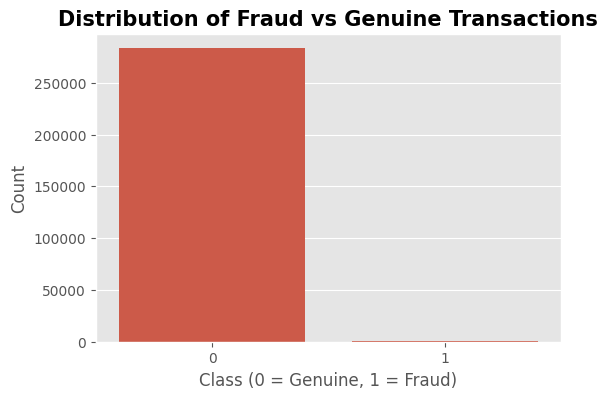

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Fraud vs Genuine Transactions",
          fontsize=15, fontweight="bold")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

### Observation

- Genuine transactions dominate the dataset.
- Fraudulent transactions represent less than **1%** of all transactions.
- This severe imbalance makes fraud detection a challenging classification problem.
- A model trained without addressing imbalance may incorrectly predict every transaction as genuine.

## EDA – Transaction Amount Analysis

Transaction amount is one of the few interpretable features in this dataset.

This visualization compares the distribution of transaction amounts for genuine and fraudulent transactions to identify behavioural differences.

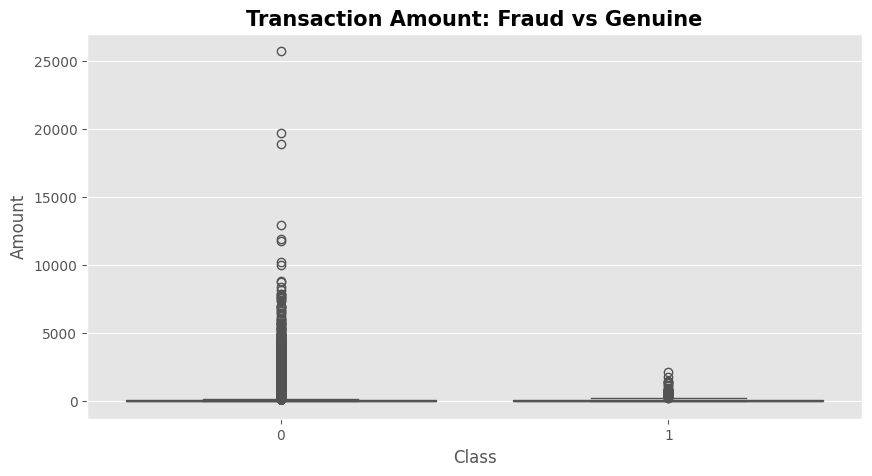

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount: Fraud vs Genuine",
          fontsize=15, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

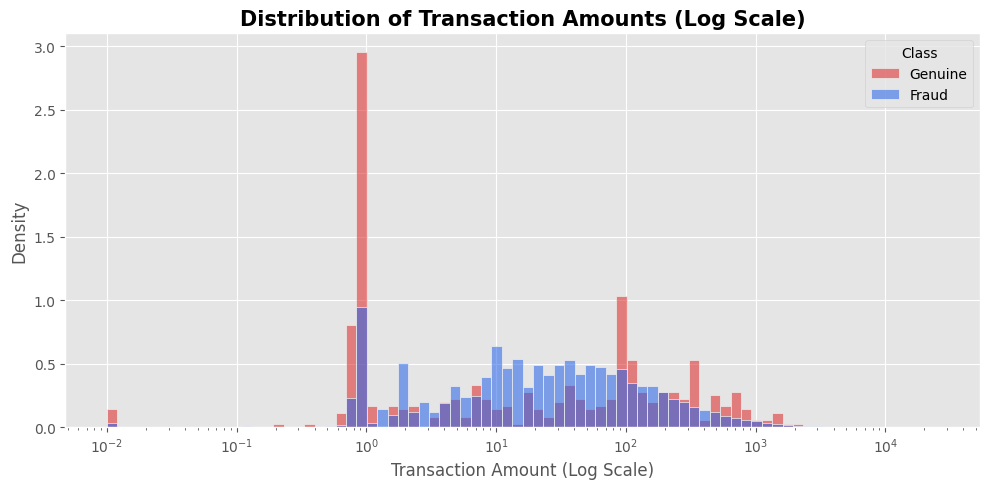

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=80,
    log_scale=True,
    stat="density",
    common_norm=False,
    alpha=0.55,
    palette={0:"#2563EB", 1:"#DC2626"}   # Blue = Genuine, Red = Fraud
)

plt.title("Distribution of Transaction Amounts (Log Scale)",
          fontsize=15, fontweight="bold")
plt.xlabel("Transaction Amount (Log Scale)")
plt.ylabel("Density")

plt.legend(title="Class", labels=["Genuine","Fraud"])

plt.tight_layout()
plt.show()

### Observation

- Most transactions involve relatively small amounts.
- Fraudulent transactions are concentrated within lower and medium transaction ranges.
- High transaction amounts are comparatively less frequent.
- Transaction amount alone is not sufficient for identifying fraud and must be combined with other features.

## EDA – Time of Day Analysis

The `Time` feature records the number of seconds elapsed since the first transaction.

To improve interpretability, it is converted into **hours of the day**, allowing us to observe whether fraudulent transactions occur more frequently during particular time periods.

In [ ]:
# Convert seconds into hour of day

df["Hour"] = (df["Time"] // 3600) % 24

df["Hour"] = df["Hour"].astype(int)

df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


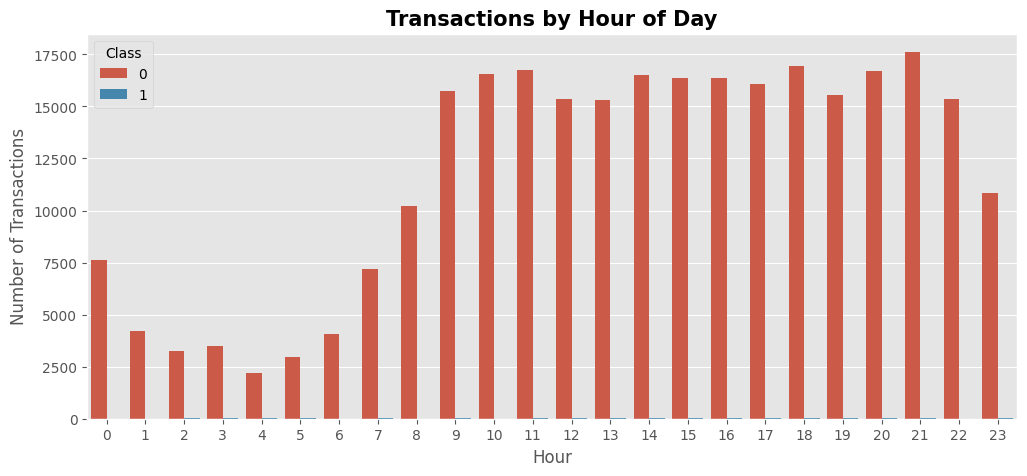

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Hour",
    hue="Class"
)

plt.title("Transactions by Hour of Day",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()

### Observation

- Genuine transactions occur throughout the day.
- Fraudulent transactions are present across multiple hours but appear more concentrated during certain periods.
- Time contributes useful behavioural information when combined with other predictive features.

# Why Accuracy is a Misleading Metric

Fraud detection is an **imbalanced classification** problem.

Imagine a dataset with **99.8% genuine transactions** and **0.2% fraud**.

A model that predicts **every transaction as genuine** would achieve approximately **99.8% accuracy**, yet it would fail to detect **every fraudulent transaction**.

Therefore, accuracy alone is not appropriate for fraud detection.

## Better Evaluation Metrics

- **Precision:** How many predicted frauds are actually fraud?
- **Recall:** How many actual frauds were detected?
- **F1-Score:** Balance between precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish fraud from genuine transactions.

For fraud detection, **Recall is often the most important metric**, because missing a fraudulent transaction can result in significant financial loss.

## Data Preprocessing

Before training the models:

1. Separate features and target variable.
2. Standardize the `Amount` feature.
3. Perform an **80/20 stratified train-test split** to preserve the fraud ratio in both datasets.

Stratification ensures that both training and testing sets contain representative samples of fraudulent transactions.

In [ ]:
# Create feature matrix and target variable

X = df.drop(columns=["Class"])
y = df["Class"]

# Scale Amount feature
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])

# Train-test split with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nTraining Fraud Distribution")
print(y_train.value_counts())

print("\nTesting Fraud Distribution")
print(y_test.value_counts())

Training Shape : (226980, 31)
Testing Shape  : (56746, 31)

Training Fraud Distribution
Class
0    226602
1       378
Name: count, dtype: int64

Testing Fraud Distribution
Class
0    56651
1       95
Name: count, dtype: int64


### Observation

- The dataset was divided into **80% training** and **20% testing** data.
- Stratified sampling preserved the proportion of fraudulent transactions in both sets.
- The `Amount` feature was standardized to improve the performance of machine learning algorithms.

## Handling Class Imbalance with SMOTE

The training dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of all records.

To address this problem, **SMOTE (Synthetic Minority Oversampling Technique)** is applied **only to the training data**.

SMOTE generates synthetic fraud samples instead of simply duplicating existing ones, helping the models learn fraud patterns more effectively while preventing data leakage into the test set.

In [ ]:
# Apply SMOTE only on training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


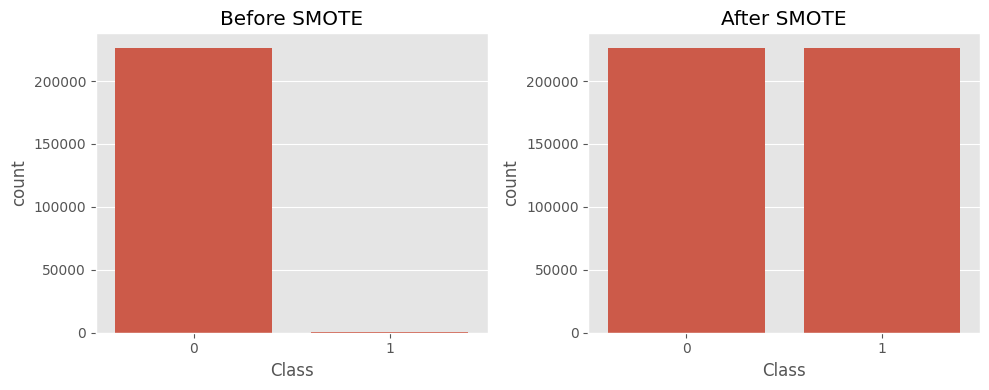

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title("Before SMOTE")

sns.countplot(x=y_train_smote, ax=ax[1])
ax[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

### Observation

- Before SMOTE, genuine transactions heavily outnumber fraudulent transactions.
- SMOTE creates synthetic fraud samples to balance the classes.
- The balanced training dataset allows the models to learn fraud characteristics more effectively without modifying the test dataset.

## Model 1 — Logistic Regression

Logistic Regression is a widely used baseline model for binary classification.

It predicts the probability that a transaction is fraudulent and provides interpretable coefficients, making it useful for comparing against more complex models.

In [ ]:
# Standardize all features for Logistic Regression

scaler_lr = StandardScaler()

X_train_scaled = scaler_lr.fit_transform(X_train_smote)
X_test_scaled = scaler_lr.transform(X_test)

# Train Logistic Regression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=5000,
    solver="lbfgs"
)

lr_model.fit(X_train_scaled, y_train_smote)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_prob))
print(classification_report(y_test, lr_pred))

Accuracy : 0.9903605540478624
Precision: 0.13192182410423453
Recall   : 0.8526315789473684
F1 Score : 0.22849083215796898
ROC AUC  : 0.9643431759926197
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.13      0.85      0.23        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.61     56746
weighted avg       1.00      0.99      0.99     56746



### Observation

Logistic Regression serves as the baseline fraud detection model.

Its Recall score is particularly important because correctly identifying fraudulent transactions is more valuable than achieving high overall accuracy.

## Model 2 — Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction performance.

It is capable of capturing complex non-linear relationships and often performs well on fraud detection datasets.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

### Observation

Random Forest generally provides stronger fraud detection performance by capturing complex patterns in the transaction data.

Its Precision and Recall scores should be compared carefully with Logistic Regression to determine the better deployment model.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


## Confusion Matrix Analysis

A confusion matrix shows how many transactions were classified correctly and incorrectly.

For fraud detection, the most critical value is **False Negatives**, which represent fraudulent transactions that were incorrectly classified as genuine.

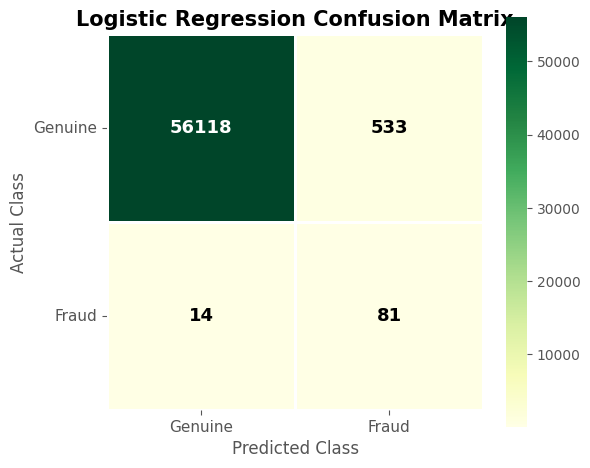

In [ ]:
# Logistic Regression Confusion Matrix (Improved)

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",          # Better contrast
    cbar=True,
    linewidths=1,
    linecolor="white",
    square=True,
    annot_kws={"fontsize":13, "fontweight":"bold"}
)

# Dynamic annotation color for readability
threshold = cm.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")

ax.set_xticklabels(["Genuine", "Fraud"], fontsize=11)
ax.set_yticklabels(["Genuine", "Fraud"], fontsize=11, rotation=0)

plt.title("Logistic Regression Confusion Matrix",
          fontsize=15, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.tight_layout()
plt.show()

### Observation

- True Positives represent correctly detected fraudulent transactions.
- False Negatives represent missed fraud cases and should be minimized.
- Comparing both confusion matrices helps identify which model detects fraud more effectively.

## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve compares the ability of both models to distinguish fraudulent and genuine transactions.

A model with a higher **Area Under the Curve (AUC)** generally has better overall discrimination performance.

<Figure size 700x600 with 0 Axes>

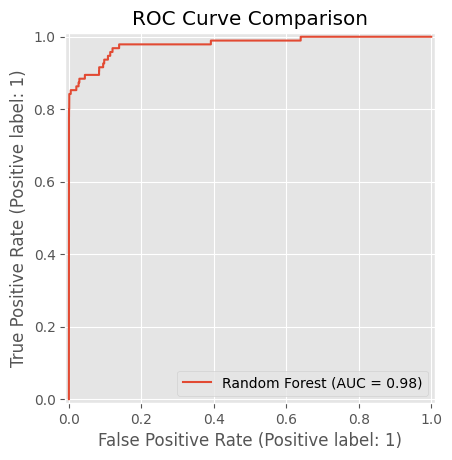

In [ ]:
plt.figure(figsize=(7,6))

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.grid(True)

plt.show()

### Observation

- The ROC curve evaluates model performance across different classification thresholds.
- A curve closer to the upper-left corner indicates stronger discrimination capability.
- The model with the higher ROC-AUC score is generally preferred for fraud detection.

## Feature Importance Analysis

Random Forest provides a feature importance score that indicates how much each feature contributes to fraud detection.

Higher importance values indicate stronger influence on the model's prediction. This helps identify which anonymized transaction features are most useful for detecting fraudulent behaviour.

In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.229342
10,V10,0.159357
12,V12,0.143593
4,V4,0.107762
17,V17,0.082678
11,V11,0.055758
2,V2,0.033696
3,V3,0.031765
9,V9,0.029893
16,V16,0.019320


/tmp/ipykernel_856/3549572377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


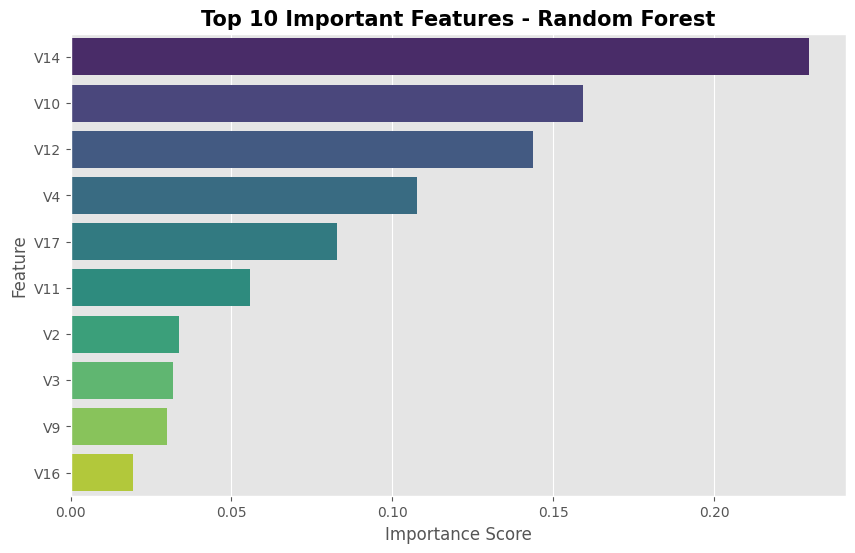

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features - Random Forest",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Observation

- The Random Forest model identifies the most influential transaction features for fraud detection.
- Features with higher importance contribute more strongly to classification decisions.
- Understanding important features improves model interpretability and supports data-driven fraud analysis.

## Model Performance Comparison

Both machine learning models are compared using the most important evaluation metrics.

Instead of relying only on accuracy, Precision, Recall, F1-Score, and ROC-AUC are used to evaluate fraud detection performance comprehensively.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9904,0.1319,0.8526,0.2285,0.9643
1,Random Forest,0.9993,0.7677,0.8000,0.7835,0.9789


/tmp/ipykernel_856/811872687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


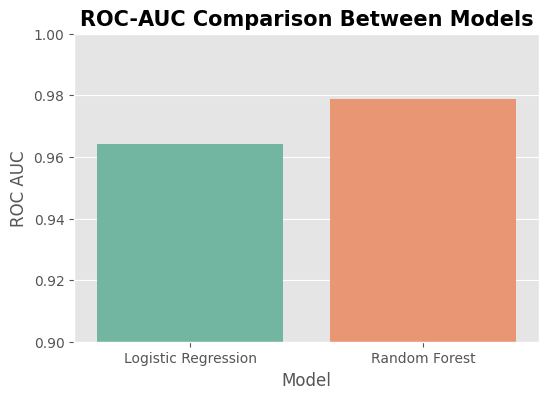

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="ROC AUC",
    palette="Set2"
)

plt.title("ROC-AUC Comparison Between Models",
          fontsize=15,
          fontweight="bold")

plt.ylim(0.9, 1.0)

plt.show()

### Observation

- The comparison table summarizes the overall performance of both models.
- ROC-AUC provides a reliable measure of fraud detection capability across different thresholds.
- The model with the higher Recall and ROC-AUC is generally more suitable for detecting fraudulent transactions.

# Scalability: Handling 1 Million Transactions per Hour

A real-world payment platform may process over **1 million transactions every hour**, making scalability an important consideration.

## How this system could scale

### Random Forest
- Provides strong fraud detection performance.
- Can process predictions quickly after training.
- Suitable for deployment using optimized inference servers.

### Logistic Regression
- Extremely fast during prediction.
- Requires less computational power.
- Suitable for high-throughput real-time systems.

## Production Architecture

A scalable fraud detection system could include:

1. Real-time transaction ingestion
2. Feature preprocessing
3. Trained ML model for prediction
4. Fraud risk score generation
5. Human review for high-risk transactions
6. Continuous model retraining with new data

This architecture enables efficient fraud detection while maintaining low prediction latency.

# Conclusion

This project successfully developed an end-to-end **Fraud Detection Machine Learning Pipeline** using a highly imbalanced credit card transaction dataset.

## Models Implemented

- Logistic Regression
- Random Forest Classifier

## Techniques Applied

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Class Imbalance Analysis
- SMOTE Oversampling
- Stratified Train/Test Split
- Feature Scaling
- Confusion Matrix
- ROC-AUC Evaluation
- Feature Importance Analysis

## Business Recommendations

### 1. Prioritize Recall
In fraud detection, missing fraudulent transactions is more costly than investigating a few additional genuine transactions. Therefore, Recall should be prioritized over accuracy alone.

### 2. Deploy Random Forest for Higher Detection Performance
If the Random Forest model achieves stronger Recall and ROC-AUC, it should be selected for production fraud detection because it captures complex transaction patterns effectively.

### 3. Continuously Retrain the Model
Fraud patterns evolve over time. Regular retraining using newly collected transaction data will improve long-term model performance.

### 4. Combine ML with Human Review
Transactions with high fraud probability should be flagged for manual verification rather than automatically blocked, reducing false positives while improving security.

Overall, this project demonstrates how machine learning can support financial institutions in identifying fraudulent transactions accurately and efficiently.